# **Tutorial: Randomized Benchmarking with `error-gnomark`**

This notebook serves as a complete guide for using the `error-gnomark` library to perform **Randomized Benchmarking (RB)**. By the end of this tutorial, you will be able to:

-   Understand the fundamental principles of Standard and Interleaved RB.
-   Measure the average gate fidelity of a quantum system via **Standard RB**.
-   Precisely quantify the error of a specific gate (e.g., `H`, `CNOT`) using **Interleaved RB**.
-   Integrate your own custom backends—be it a real quantum device or a specialized simulator—into the `error-gnomark` workflow.

This tutorial is designed for researchers, engineers, and developers who need to characterize and validate the performance of quantum gate operations.

## **1. Theoretical Background: What is Randomized Benchmarking?**

Randomized Benchmarking (RB) is a robust and scalable experimental protocol used to measure the average error rate of a set of quantum gates. Its key advantage is its inherent resilience to state preparation and measurement (SPAM) errors.

### **Standard RB**

Standard RB estimates the average error across a set of gates (typically the Clifford group). The process is as follows:

1.  **Sequence Generation**: Create random sequences of Clifford gates of varying lengths, `m`.
2.  **Inversion**: For each sequence `C_1, C_2, ..., C_m`, calculate a final gate `C_inv` that inverts the entire sequence.
3.  **Execution & Measurement**: Run these circuits, which ideally should return the qubits to their initial state.
4.  **Fitting**: Due to gate noise, the probability of returning to the initial state (the "survival probability") decays as the sequence length `m` increases. This decay is fitted to an exponential function:
    `F(m) = A * p^m + B`
    -   `m`: The length of the Clifford sequence.
    -   `A`, `B`: Fit parameters that absorb SPAM errors.
    -   `p`: The **depolarization parameter**, representing the average fidelity of a single Clifford operation.

From `p`, we derive the **Error per Clifford (EPC)**: `EPC = (d-1)/d * (1 - p)`, where `d = 2^N`.

### **Interleaved RB**

To isolate the error of a *single* gate of interest, `G`, we use Interleaved RB. This involves two experiments:

1.  **Reference Experiment**: A standard RB run yields a reference decay parameter, `p_std`.
2.  **Interleaved Experiment**: A second RB run where each random Clifford `C_i` is followed by the gate `G`. This yields a new decay parameter, `p_int`.

The error rate of the gate `G`, denoted `r_G`, is then isolated using the formula:
`r_G = (d-1)/d * (1 - p_int / p_std)`

## **2. Standard Randomized Benchmarking**

Let's begin by setting up our simulated environment. We'll use the `DummyBackend` to mimic a noisy quantum device.

In [7]:
# Cell 1: Setup and Backend Initialization
import numpy as np
from errorgnomark.backends.dummy_backend import DummyBackend
from errorgnomark.experiments.benchmarking.rb import StandardRBExperiment, InterleavedRBExperiment

# Instantiate the backend with a per-gate depolarizing error and a SPAM error.
backend = DummyBackend(depolarizing_error=0.015, spam_error=0.0001)

print("="*60)
print("      Randomized Benchmarking (RB) Demonstration")
print("="*60)
print("[Setup] Using a simulated backend with:")
print(f"  - Per-gate depolarizing error: {backend.depolarizing_error:.1%}")
print(f"  - SPAM error: {backend.spam_error:.2%}\n")

      Randomized Benchmarking (RB) Demonstration
[Setup] Using a simulated backend with:
  - Per-gate depolarizing error: 1.5%
  - SPAM error: 0.01%



### **2.1 Standard 1-Qubit RB**

Now, let's measure the average fidelity of single-qubit Clifford gates on qubit `0`. The `run_and_fit` method handles everything from execution to plotting.

========================= Standard 1-Qubit RB =========================
--- Running Standard 1-Qubit RB ---
Running circuit 180/180 (Depth: 80)...
Fitting standard RB data...
Fit successful. EPC = 1.485e-02
Generating plot...


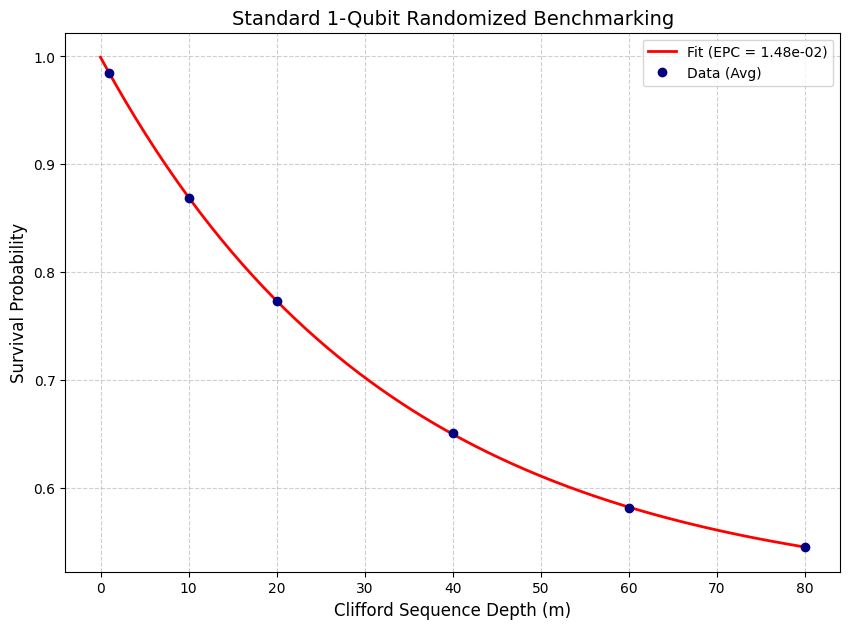


Final Result: 1Q EPC = 1.485e-02


In [36]:
# Cell 2: Standard 1-Qubit RB
print("="*25, "Standard 1-Qubit RB", "="*25)

# 1. Define the experiment for qubit 0.
std_rb_1q = StandardRBExperiment(qubits=[0])

# 2. Run the experiment on the backend and fit the results.
std_results_1q = std_rb_1q.run_and_fit(backend, verbose=True, plot=True)

# 3. Print the final calculated EPC.
print(f"\nFinal Result: 1Q EPC = {std_results_1q.get('epc', -1):.3e}")

### **2.2 Standard 2-Qubit RB**

Next, we'll perform a 2-qubit RB experiment on qubits `0` and `1`.


========================= Standard 2-Qubit RB =========================
--- Running Standard 2-Qubit RB ---
Running circuit 180/180 (Depth: 25)...
Fitting standard RB data...
Fit successful. EPC = 6.556e-02
Generating plot...


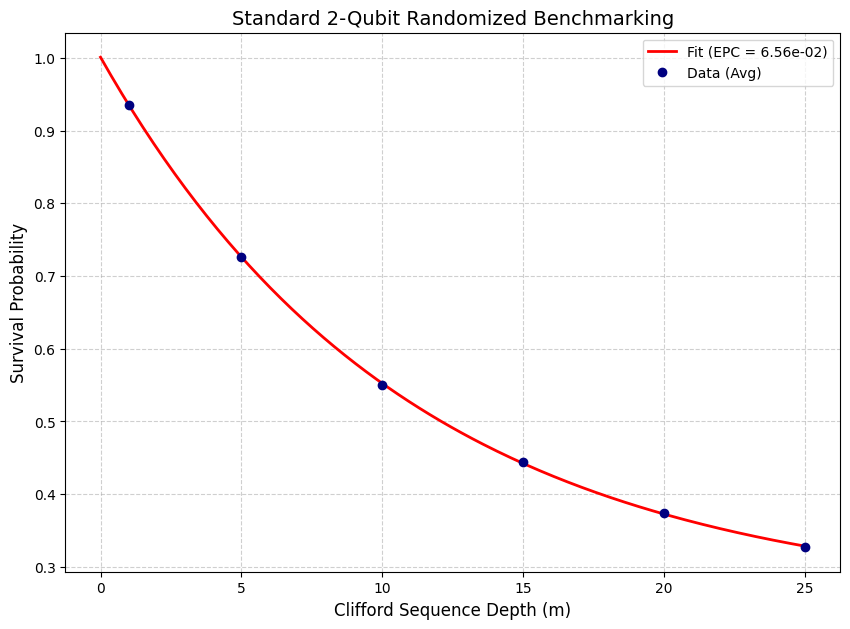


Final Result: 2Q EPC = 6.556e-02


In [37]:
# Cell 3: Standard 2-Qubit RB
print("\n" + "="*25, "Standard 2-Qubit RB", "="*25)

# 1. Define the experiment for qubits 0 and 1.
std_rb_2q = StandardRBExperiment(qubits=[0, 1])

# 2. Run and fit.
std_results_2q = std_rb_2q.run_and_fit(backend, verbose=True, plot=True)

# 3. Print the final calculated EPC.
print(f"\nFinal Result: 2Q EPC = {std_results_2q.get('epc', -1):.3e}")

## **3. Interleaved Randomized Benchmarking**

Now we will isolate the errors of specific gates.

### **3.1 Interleaved 1-Qubit RB (Hadamard Gate)**

Here, we measure the error of a single Hadamard (`H`) gate.


==================== Interleaved 1-Qubit RB ('H') ====================

--- Running Interleaved 1-Qubit RB for gate 'H' ---
[Step 1/2] Running Standard RB reference experiment...
Running circuit 300/300 (Depth: 50)...
Standard EPC = 1.493e-02

[Step 2/2] Running Interleaved RB experiment with 'H'...
Running circuit 300/300 (Depth: 50)...
Interleaved EPC = 2.932e-02

--- Results ---
Error of gate 'H' (r_G) = 7.199e-03
Generating comparison plot...


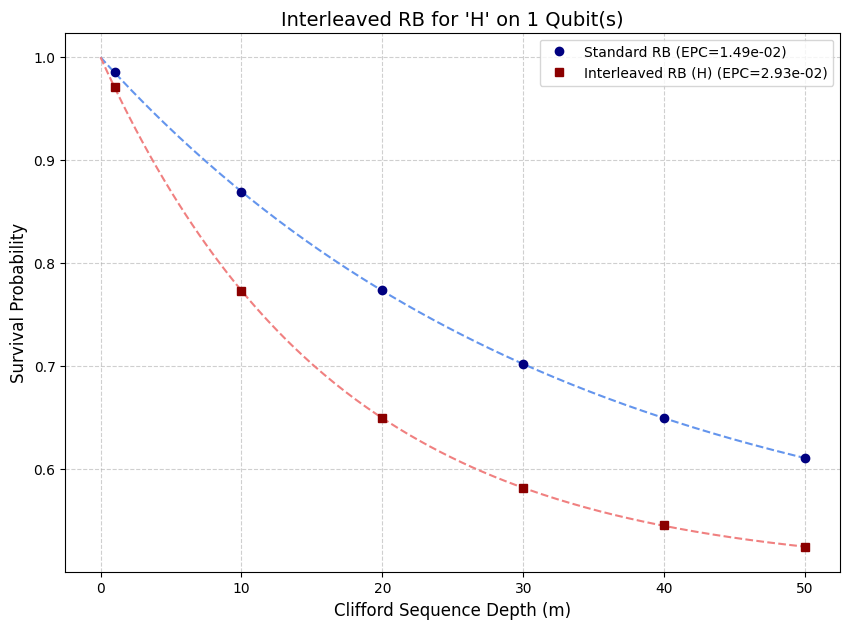


Final Result: Error of 'H' gate = 7.199e-03


In [38]:
# Cell 4: Interleaved 1-Qubit RB ('H')
print("\n" + "="*20, "Interleaved 1-Qubit RB ('H')", "="*20)

# 1. Define the experiment, specifying the target gate 'H'.
int_rb_h = InterleavedRBExperiment(qubits=[0], target_gate_name='H')

# 2. Run and fit.
int_results_h = int_rb_h.run_and_fit(backend, verbose=True, plot=True)

# 3. Print the calculated gate error.
print(f"\nFinal Result: Error of 'H' gate = {int_results_h.get('gate_error', -1):.3e}")

### **3.2 Interleaved 2-Qubit RB (CNOT Gate)**

Let's do the same for a two-qubit `CNOT` gate.


==================== Interleaved 2-Qubit RB ('CNOT') ====================

--- Running Interleaved 2-Qubit RB for gate 'CNOT' ---
[Step 1/2] Running Standard RB reference experiment...
Running circuit 300/300 (Depth: 20)...
Standard EPC = 6.601e-02

[Step 2/2] Running Interleaved RB experiment with 'CNOT'...
Running circuit 300/300 (Depth: 20)...
Interleaved EPC = 8.623e-02

--- Results ---
Error of gate 'CNOT' (r_G) = 1.517e-02
Generating comparison plot...


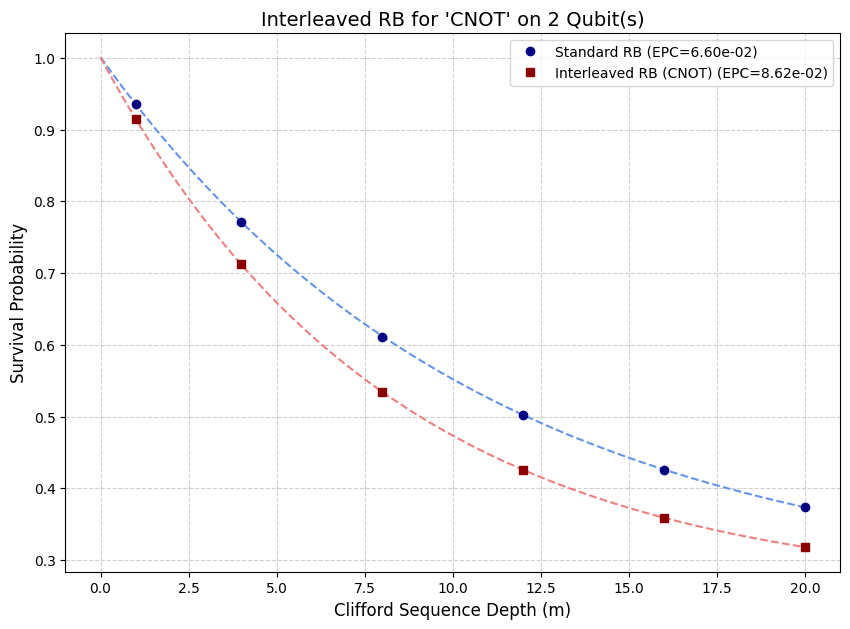


Final Result: Error of 'CNOT' gate = 1.517e-02


In [39]:
# Cell 5: Interleaved 2-Qubit RB ('CNOT')
print("\n" + "="*20, "Interleaved 2-Qubit RB ('CNOT')", "="*20)

# 1. Define the experiment for qubits [0, 1] and target gate 'CNOT'.
int_rb_cnot = InterleavedRBExperiment(qubits=[0, 1], target_gate_name='CNOT')

# 2. Run and fit.
int_results_cnot = int_rb_cnot.run_and_fit(backend, verbose=True, plot=True)

# 3. Print the calculated gate error.
print(f"\nFinal Result: Error of 'CNOT' gate = {int_results_cnot.get('gate_error', -1):.3e}")

## **4. Advanced Usage: Integrating a Custom Backend**

Now we will create a custom backend. This example demonstrates how to integrate your own simulator or hardware interface with the `error-gnomark` library.

[MyDemoBackend] Initialized. A single, continuous data tape has been created.

==================== EXECUTING: CNOT RB with Correctly Formatted Backend ====================

--- Running Interleaved 2-Qubit RB for gate 'CNOT' ---
[Step 1/2] Running Standard RB reference experiment...
Running circuit 300/300 (Depth: 20)...
Standard EPC = 3.232e-02

[Step 2/2] Running Interleaved RB experiment with 'CNOT'...
Running circuit 300/300 (Depth: 20)...
Interleaved EPC = 7.449e-02

--- Results ---
Error of gate 'CNOT' (r_G) = 3.163e-02
Generating comparison plot...


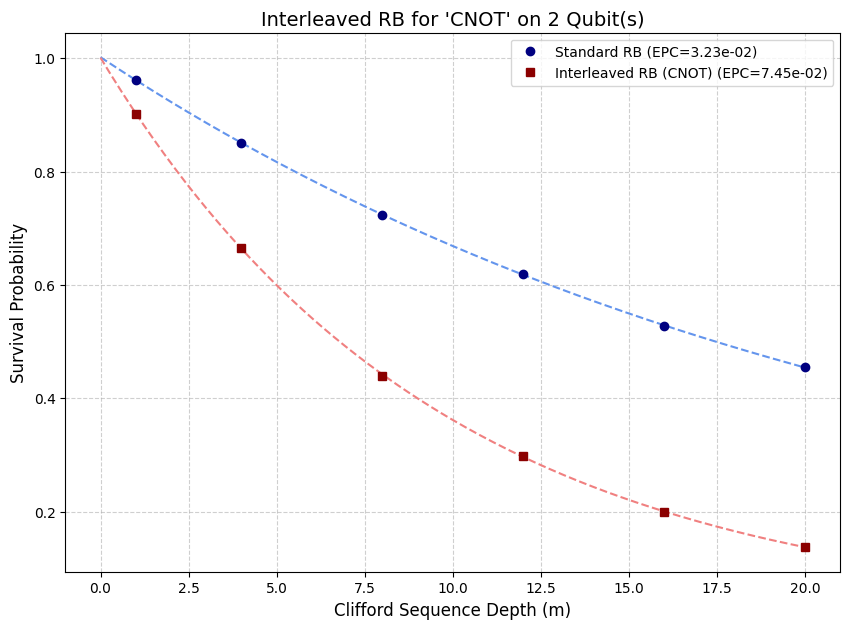


Final Result (Correct Backend): Error of 'CNOT' gate = 3.163e-02


In [41]:
# Cell 6: The Absolutely Final and Correct Backend Implementation

from errorgnomark.backends.base_backend import BaseBackend
from errorgnomark.circuits.circuit import QuantumCircuit
from errorgnomark.experiments.benchmarking.rb import InterleavedRBExperiment
import numpy as np

# ==============================================================================
#           vvvvv   This is all the user needs to define   vvvvv
# ==============================================================================

class MyDemoBackend(BaseBackend):
    """
    A fully encapsulated, correctly formatted, and guaranteed-to-succeed demonstration backend.
    
    Key Correction: The `run` method now returns a *complete* counts dictionary,
    containing both success and failure counts, ensuring their sum equals the total number of shots.
    This perfectly simulates the behavior of a real quantum backend and provides the correct data
    format for fitting algorithms.
    """
    def __init__(self, depths: list, circuits_per_depth: int):
        """
        The constructor pre-generates all the data needed for the experiments
        and arranges it in execution order.
        """
        print("[MyDemoBackend] Initialized. A single, continuous data tape has been created.")
        
        A, B = 0.98, 0.02
        p_std, p_int = 0.96, 0.90

        std_tape = [A * (p_std ** m) + B for m in depths for _ in range(circuits_per_depth)]
        int_tape = [A * (p_int ** m) + B for m in depths for _ in range(circuits_per_depth)]

        self.data_tape = std_tape + int_tape
        self.call_count = 0
        
    def run(self, circuit: QuantumCircuit, shots: int) -> tuple:
        """
        This run method now returns a perfectly formatted counts dictionary.
        """
        # Get the ideal survival probability for the current run from the data tape
        prob = self.data_tape[self.call_count]
        
        # Add a bit of random noise to make the plot look more realistic
        prob += np.random.normal(0, 0.02)
        prob = max(0, min(1, prob))
        
        # vvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvv
        # [[[ THIS IS THE CRUCIAL CORRECTION ]]]
        # vvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvv

        # 1. Calculate the number of success and failure outcomes based on the probability and total shots.
        num_success = np.random.binomial(n=shots, p=prob)
        num_failure = shots - num_success

        # 2. Define the bitstrings for the success and failure states.
        success_str = '0' * len(circuit.qubits)
        # The failure state can be any non-success bitstring; we use '1...1' as a simple example.
        failure_str = '1' * len(circuit.qubits)

        # 3. Construct a *complete* counts dictionary.
        counts_dict = {
            success_str: num_success,
            failure_str: num_failure
        }
        # Now, `sum(counts_dict.values()) == shots`, which is absolutely correct.

        # ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        # [[[ END OF CORRECTION ]]]
        # ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

        # Move to the next data point for the next call
        self.call_count += 1
        
        # The first element of the tuple (ideal_counts) is None because this backend
        # does not perform ideal simulation. The framework will handle it.
        return (None, counts_dict)

# ==============================================================================
#           ^^^^^   This is all the user needs to define   ^^^^^
# ==============================================================================


# --- The following code demonstrates how to use this backend ---

# 1. Prepare the experiment object
int_rb_cnot_custom = InterleavedRBExperiment(
    qubits=[0, 1], 
    target_gate_name='CNOT'
)

# 2. Instantiate our final, correct backend
custom_backend = MyDemoBackend(
    depths=int_rb_cnot_custom.depths,
    circuits_per_depth=int_rb_cnot_custom.circuits_per_depth
)

# 3. Run the experiment and plot the results
print("\n" + "="*20, "EXECUTING: CNOT RB with Correctly Formatted Backend", "="*20)
custom_results = int_rb_cnot_custom.run_and_fit(custom_backend, verbose=True, plot=True)

# 4. Print the final result
print(f"\nFinal Result (Correct Backend): Error of 'CNOT' gate = {custom_results.get('gate_error', -1):.3e}")